In [1]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Generator, Tuple

from utilities.get_images import get_images

%matplotlib inline

In [2]:
MNIST_PATH = "data/mnist_raw"

x_train_num, y_train_num, x_test_num, y_test_num = get_images(MNIST_PATH)

x_train = x_train_num[:50000].reshape(50000, -1).astype(float)
y_train = y_train_num[:50000].reshape(50000, 1)

x_val = x_train_num[50000:].reshape(10000, -1).astype(float)
y_val = y_train_num[50000:].reshape(10000, 1)

x_test = x_test_num.copy().reshape(10000, -1).astype(float)
y_test = y_test_num.copy().reshape(10000, 1)

In [3]:
print(x_train.shape)

(50000, 784)


In [4]:
print(F"X train mean: {x_train.mean()}\nX train std: {x_train.std()}\nX train min: {x_train.min()}\nX train max: {x_train.max()}")

X train mean: 33.39512885204082
X train std: 78.6661972212754
X train min: 0.0
X train max: 255.0


In [5]:
def normalise(x_mean: float, x_std: float, x_data: np.ndarray) -> float:
    """
    Normalises the input data using the provided mean and standard deviation.
    Transforms the data to have a mean of 0 and a standard deviation of 1.
    Args:
        x_mean: Mean of the training data
        x_std: Standard deviation of the training data
        x_data: Data to be normalised
    Returns:
        Normalised data
    """
    return (x_data - x_mean) / x_std

In [6]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)

In [7]:
x_train.shape

(50000, 784)

In [8]:
print(F"X train mean: {x_train.mean()}\nX train std: {x_train.std()}\nX train min: {x_train.min()}\nX train max: {x_train.max()}")

X train mean: -9.646705203355238e-18
X train std: 0.9999999999999997
X train min: -0.4245168831296837
X train max: 2.817027884602331


In [9]:
def plot_number(image: np.ndarray) -> None:
    """
    Plot a given image using matplotlib.
    Args:
        image: an image in np.ndarray
    Returns:
        None
    """
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

Number: 8


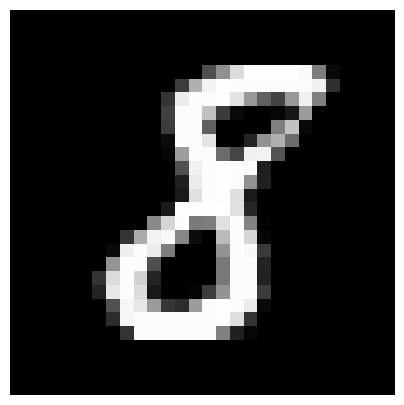

In [10]:
rnd_idx = np.random.randint(len(y_test))
print(f'Number: {y_test[rnd_idx, 0]}')
plot_number(x_test_num[rnd_idx])

### Equations


$$z^1 = W^1 X + b^1$$

$$a^1 = ReLU(z^1) $$

$$z^2 = W^2 a^1 + b^2$$

$$\hat{y} = \frac{e^{z^{2_k}}}{\sum_j{e^{z_j}}}$$


$$ \mathcal{L}(\hat{y}^{i}, y^{i}) =  - y^{i}  \ln(\hat{y}^{i}) = -\ln(\hat{y}^i)$$


$$ \mathcal{J}(w, b) =  \frac{1}{num\_samples} \sum_{i=1}^{num\_samples}-\ln(\hat{y}^{i})$$

## Helper functions

In [11]:
def create_minibatches(mb_size: int, 
                       x: np.ndarray, 
                       y: np.ndarray, 
                       shuffle: bool = True) -> Generator[Tuple[np.ndarray, np.ndarray], None, None]:
    """
    Creates mini batches given the size and the x input data.
    Ars:
        mb_size: batch size
        x: input data to create the batches
        y: label data
        shuffle: boolean option to shuffle the data
    Returns:
        Generator of tuples with mini batches of (x, y)
    """
    assert x.shape[0] == y.shape[0], f"[ERROR] Sample size of x {x.shape[0]} and y {y.shape[0]} must be the same."
    total_data = x.shape[0]
    if shuffle:
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
    return ((x[i:i+mb_size], y[i:i+mb_size]) for i in range(0, total_data, mb_size))

In [12]:
class np_tensor(np.ndarray): 
    """
    A subclass of np.ndarray for tensor operations.
    Args:
        np.ndarray: base class
    Returns:
        np_tensor: subclass of np.ndarray
    """
    pass

a = np.array([0, 0])
b = a.view(np_tensor)

print(f"Type a: {type(a)}")
print(f"Type b: {type(b)}")

Type a: <class 'numpy.ndarray'>
Type b: <class '__main__.np_tensor'>


In [13]:
print(a == b)
print(a is b)

[ True  True]
False


## Model creation

### Linear layer

In [14]:
class Linear():
    def __init__(self, input_size: int, output_size: int) -> None:
        """
        Initializes the linear layer with weights and biases.
            - Weights are initialized using He initialization.
        Args:
            input_size: Size of the input features
            output_size: Size of the output features
        Returns:
            None
        """
        self.W = (np.random.randn(output_size, input_size) / np.sqrt(input_size/2)).view(np_tensor)
        self.b = (np.zeros((output_size, 1))).view(np_tensor)

    def __call__(self, X: np.ndarray) -> np.ndarray:
        """
        Forward pass of the linear layer.
            - Computes: Z = W X + b
        Args:
            X: Input data
        Returns:
            Z: Output data
        """
        Z = self.W @ X + self.b
        return Z

    def backward(self, X: np.ndarray, Z: np.ndarray) -> None:
        """
        Backward pass of the linear layer.
            - Given upstream gradient dL/dZ, compute: dL/dX, dL/dW, dL/db
        Args:
            X: Input data
            Z: Output data
        Returns:
            None
        """
        # dL/dX = Wᵀ · dL/dZ
        # Propagates the gradient to the input of the layer
        X.grad = self.W.T @ Z.grad

        # dL/dW = dL/dZ · Xᵀ
        # Gradient of the loss w.r.t. the weights
        self.W.grad = Z.grad @ X.T

        # dL/db = Σ dL/dZ (sum over batch dimension)
        # Gradient of the loss w.r.t. the bias
        self.b.grad = np.sum(Z.grad, axis = 1, keepdims=True)


### Activation function

In [15]:
class ReLU():
    def __call__(self, Z: np.ndarray):
        """
        Forward pass of the ReLU activation function.
            - Computes: A = max(0, Z)
        Args:
            Z: Input data
        Returns:
            A: Activated output
        """
        return np.maximum(0, Z)

    def backward(self, Z: np.ndarray, A: np.ndarray) -> None:
        """
        Backward pass of the ReLU activation function.
            - Given upstream gradient dL/dA, compute: dL/dZ = dL/dA ⊙ 𝟙(Z > 0)
        Args:
            Z: Input data
            A: Activated output
        Returns:
            None
        """
        # Initialize dL/dZ with upstream gradient dL/dA
        Z.grad = A.grad.copy()

        # Apply ReLU derivative:
        # gradient is zero where Z ≤ 0, unchanged where Z > 0
        Z.grad[Z <= 0] = 0

### Sequential layers

In [16]:
class Sequential_layers():
    def __init__(self, layers: list) -> None:
        """
        Layers - list containing objects of type Linear, ReLU
        Args:
            layers: list of layer objects
        Returns:
            None
        """
        self.layers = layers
        self.x = None
        self.outputs = {}

    def __call__(self, X: np.ndarray) -> np.ndarray:
        """
        Computes the forward pass through all layers.
        Args:
            X: Input data
        Returns:
            Output after passing through all layers
        """
        self.x = X
        self.outputs['l0'] = self.x
        for i, layer in enumerate(self.layers, 1):
            self.x = layer(self.x)
            self.outputs['l'+str(i)]=self.x
        return self.x

    def backward(self) -> None:
        """
        Computes the backward pass through all layers.
        Args:
            None
        Returns:
            None
        """
        for i in reversed(range(len(self.layers))):
            self.layers[i].backward(self.outputs['l'+str(i)], self.outputs['l'+str(i+1)])

    def update(self, learning_rate: float = 1e-3) -> None:
        """
        Updates the weights and biases of the linear layers using gradient descent.
        Args:
            learning_rate: Learning rate for the update step
        Returns:
            None
        """
        for layer in self.layers:
            if isinstance(layer, ReLU): continue
            layer.W = layer.W - learning_rate * layer.W.grad
            layer.b = layer.b - learning_rate * layer.b.grad

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predicts the class label for the input data X.
        Args:
            X: Input data
        Returns:
            Predicted class label
        """
        return np.argmax(self.__call__(X))

## Cost function

In [17]:
def softmaxXEntropy(x: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Computes the softmax activation and cross-entropy loss.
    Args:
        x: Input logits (shape: num_classes x batch_size)
        y: True labels (shape: 1 x batch_size)
    Returns:
        preds: Softmax probabilities
    """
    batch_size = x.shape[1]
    exp_scores = np.exp(x) 
    probs = exp_scores / exp_scores.sum(axis = 0)
    preds = probs.copy()
    
    # Cost calculation
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    cost = np.sum(-np.log(y_hat)) / batch_size
    
    # Gradient calculation
    probs[y.squeeze(), np.arange(batch_size)] -= 1 # dl/dx
    x.grad = probs.copy()

    return preds, cost

## Training loop

In [18]:
def accuracy(x: np.ndarray, y: np.ndarray, mb_size: int, model: Sequential_layers) -> float:
    """
    Computes the accuracy of the model on the given data.
    Args:
        x: Input data
        y: True labels
        mb_size: Mini-batch size
        model: The neural network model
    Returns:
        Accuracy as a float between 0 and 1
    """
    correct = 0
    total = 0
    for i, (x, y) in enumerate(create_minibatches(mb_size, x, y)):
        pred = model(x.T.view(np_tensor))
        correct += np.sum(np.argmax(pred, axis=0) == y.squeeze())
        total += pred.shape[1]
    return correct/total

In [19]:
def train(model: Sequential_layers, epochs: int, mb_size:int = 128, learning_rate:float  = 1e-3) -> None:
    """
    Trains the model using mini-batch gradient descent.
    Args:
        model: The neural network model to be trained
        epochs: Number of epochs to train
        mb_size: Mini-batch size
        learning_rate: Learning rate for gradient descent
    Returns:
        None
    """
    for epoch in range(epochs):
        for i, (x, y) in enumerate(create_minibatches(mb_size, x_train, y_train)):
            scores = model(x.T.view(np_tensor))
            _, cost = softmaxXEntropy(scores, y)
            model.backward()
            model.update(learning_rate)
        print(f'Epoch {epoch+1} ---> Cost value: {cost:.5f}\tAccuracy: {accuracy(x_val, y_val, mb_size, model)*100:.2f}%')

In [20]:
model = Sequential_layers(
    [
        Linear(784, 200), 
        ReLU(),
        Linear(200, 200),
        ReLU(),
        Linear(200, 10)
     ])

EPOCHS = 20
MB_SIZE = 512
LEARNING_RATE = 1e-4

train(model, 
      EPOCHS, 
      MB_SIZE, 
      LEARNING_RATE)

Epoch 1 ---> Cost value: 0.28889	Accuracy: 91.61%
Epoch 2 ---> Cost value: 0.30179	Accuracy: 93.40%
Epoch 3 ---> Cost value: 0.18259	Accuracy: 94.67%
Epoch 4 ---> Cost value: 0.17886	Accuracy: 95.20%
Epoch 5 ---> Cost value: 0.12553	Accuracy: 95.67%
Epoch 6 ---> Cost value: 0.11752	Accuracy: 96.10%
Epoch 7 ---> Cost value: 0.12708	Accuracy: 96.25%
Epoch 8 ---> Cost value: 0.12815	Accuracy: 96.41%
Epoch 9 ---> Cost value: 0.11691	Accuracy: 96.61%
Epoch 10 ---> Cost value: 0.08816	Accuracy: 96.69%
Epoch 11 ---> Cost value: 0.11281	Accuracy: 96.82%
Epoch 12 ---> Cost value: 0.07618	Accuracy: 96.89%
Epoch 13 ---> Cost value: 0.08853	Accuracy: 97.01%
Epoch 14 ---> Cost value: 0.07622	Accuracy: 97.07%
Epoch 15 ---> Cost value: 0.08971	Accuracy: 97.09%
Epoch 16 ---> Cost value: 0.09120	Accuracy: 97.03%
Epoch 17 ---> Cost value: 0.07117	Accuracy: 97.17%
Epoch 18 ---> Cost value: 0.06222	Accuracy: 97.27%
Epoch 19 ---> Cost value: 0.05048	Accuracy: 97.28%
Epoch 20 ---> Cost value: 0.05384	Accura

## Testing model

In [21]:
print(f"Test accuracy: {accuracy(x_test, y_test, MB_SIZE, model)*100:,.2f}%")

Test accuracy: 97.01%


Predicted number is: 	1
Actual number is: 	1


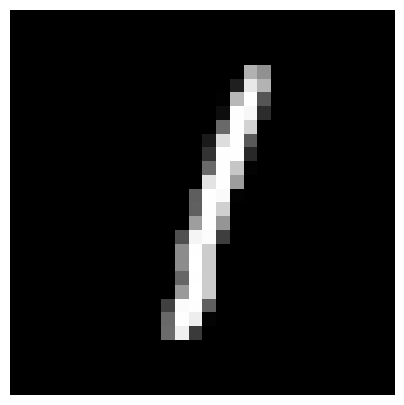

In [22]:
idx = np.random.randint(len(y_test))

pred = model.predict(x_test[idx].reshape(-1, 1))

print(f'Predicted number is: \t{pred}\nActual number is: \t{y_test[idx][0]}')
plot_number(x_test_num[idx])